<a href="https://colab.research.google.com/github/anitinfo16-dot/INTERNSHIP-PROJECTS/blob/main/VGG16_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Required Libraries

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

Load and sample fashion_MNIST dataset

In [4]:
(x_train, y_train),(x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
x_train, y_train = x_train[:100], y_train[:100]
x_test, y_test = x_test[:100],y_test[:100]

Resize Images to 224*224

In [7]:
x_train=tf.image.resize(x_train,(224,224))
x_test=tf.image.resize(x_test,(224,224))

Normalization

In [8]:
x_train=x_train/255.0
x_test=x_test/255.0

One hot encoding

In [9]:
(_,y_train_full),(_,y_test_full)=tf.keras.datasets.fashion_mnist.load_data()
y_train=y_train_full[:100]
y_test=y_test_full[:100]
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)



Load Pretrained VGG16 without top layers

In [10]:
base_model=VGG16(weights='imagenet',include_top=False,input_shape=(224,224,3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze Basemodel layers(Feature extraction)

In [11]:
for layer in base_model.layers:
  layer.trainable=False

Add custom top layers

In [12]:
x=base_model.output
x=Flatten()(x)
x=Dense(256,activation="relu")(x)
x=Dropout(0.5)(x)
predictions=Dense(10,activation="softmax")(x)


Create the final model

In [13]:
model=Model(inputs=base_model.input,outputs=predictions)

Compile the model(Feature extraction Phase)

In [14]:
model.compile(optimizer=Adam(learning_rate=1e-4),loss='categorical_crossentropy',metrics=['accuracy'])

Train the model(Only top layers)

In [15]:
(raw_x_train,raw_y_train),(_,_)=tf.keras.datasets.fashion_mnist.load_data()
x_train_processed=raw_x_train[:100]
y_train_processed=raw_y_train[:100]
x_train_processed=tf.cast(x_train_processed,tf.float32)/255.0
x_train_processed=tf.expand_dims(x_train_processed,axis=-1)
x_train_processed=tf.image.resize(x_train_processed,(224,224))
x_train_processed=tf.image.grayscale_to_rgb(x_train_processed)
y_train_processed=to_categorical(y_train_processed)
y_train_processed=tf.cast(y_train_processed,tf.float32)
print("Shape of x_train_processed before model.fit:{x_train_processed.shape}")
print("Shape of y_train_processed before model.fit:{y_train_processed.shape}")
history=model.fit(x_train_processed.numpy(),y_train_processed.numpy(),epochs=5,batch_size=32,validation_split=0.2)

Shape of x_train_processed before model.fit:{x_train_processed.shape}
Shape of y_train_processed before model.fit:{y_train_processed.shape}
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 83s 25s/step - accuracy: 0.1000 - loss: 2.6420 - val_accuracy: 0.2500 - val_loss: 2.2070
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 69s 25s/step - accuracy: 0.2250 - loss: 2.2286 - val_accuracy: 0.3000 - val_loss: 2.0883
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 24s/step - accuracy: 0.3125 - loss: 1.8599 - val_accuracy: 0.3500 - val_loss: 1.7968
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 67s 24s/step - accuracy: 0.3875 - loss: 1.6457 - val_accuracy: 0.5500 - val_loss: 1.5091
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 24s/step - accuracy: 0.6625 - loss: 1.2702 - val_accuracy: 0.6500 - val_loss: 1.2890


Fine-tune some convolutional Layers

In [16]:
for layer in base_model.layers[-4:]:
  layer.trainable=True

compile again(after unfreezing)

In [17]:
model.compile(optimizer=Adam(learning_rate=1e-5),loss='categorical_crossentropy',metrics=['accuracy'])

In [18]:
(raw_x_train,raw_y_train),(_,_)=tf.keras.datasets.fashion_mnist.load_data()
x_train_fine=raw_x_train[:100]
y_train_fine=raw_y_train[:100]
x_train_fine=tf.cast(x_train_fine,tf.float32)/255.0
x_train_fine=tf.expand_dims(x_train_fine,axis=-1)
x_train_fine=tf.image.resize(x_train_fine,(224,224))
x_train_fine=tf.image.grayscale_to_rgb(x_train_fine)
y_train_fine=to_categorical(y_train_fine)
y_train_fine=tf.cast(y_train_fine,tf.float32)
print("Shape of x_train_fine before model.fit:{x_train_fine.shape}")
print("Shape of y_train_fine before model.fit:{y_train_fine.shape}")
history_fine=model.fit(x_train_fine.numpy(),y_train_fine.numpy(),epochs=5,batch_size=32,validation_split=0.2)

Shape of x_train_fine before model.fit:{x_train_fine.shape}
Shape of y_train_fine before model.fit:{y_train_fine.shape}
Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 84s 28s/step - accuracy: 0.6750 - loss: 1.1998 - val_accuracy: 0.7000 - val_loss: 1.1748
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 69s 23s/step - accuracy: 0.7000 - loss: 1.0404 - val_accuracy: 0.7500 - val_loss: 1.1257
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 91s 28s/step - accuracy: 0.7250 - loss: 0.9816 - val_accuracy: 0.7000 - val_loss: 1.0867
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 77s 27s/step - accuracy: 0.7750 - loss: 0.8512 - val_accuracy: 0.7000 - val_loss: 1.0501
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 27s/step - accuracy: 0.7250 - loss: 0.8835 - val_accuracy: 0.7000 - val_loss: 1.0029


Evaluate on test set

In [19]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
(raw_x_test,raw_y_test),(_,_)=tf.keras.datasets.fashion_mnist.load_data()
x_test_processed=raw_x_test[:100]
y_test_processed=raw_y_test[:100]
x_test_processed=tf.cast(x_test_processed,tf.float32)/255.0
x_test_processed=tf.expand_dims(x_test_processed,axis=-1)
x_test_processed=tf.image.resize(x_test_processed,(224,224))
x_test_processed=tf.image.grayscale_to_rgb(x_test_processed)
y_test_processed=to_categorical(y_test_processed)
y_test_processed=tf.cast(y_test_processed,tf.float32)
print("Shape of x_test_processed before model.evaluate:{x_test_processed.shape}")
print("Shape of y_test_processed before model.evaluate:{y_test_processed.shape}")
test_loss,test_acc=model.evaluate(x_test_processed.numpy(),y_test_processed.numpy())
print("Test accuracy:",test_acc)
print("Test loss:",test_loss)


Shape of x_test_processed before model.evaluate:{x_test_processed.shape}
Shape of y_test_processed before model.evaluate:{y_test_processed.shape}
4/4 ━━━━━━━━━━━━━━━━━━━━ 64s 13s/step - accuracy: 0.8500 - loss: 0.7045
Test accuracy: 0.8500000238418579
Test loss: 0.7045195698738098


Plot accuracy graph

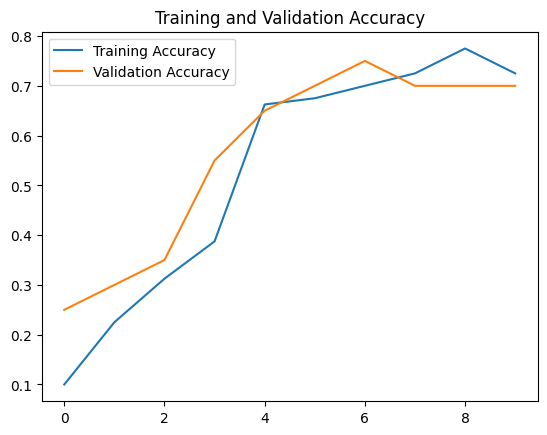

In [20]:
plt.plot(history.history['accuracy']+history_fine.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy']+history_fine.history['val_accuracy'],label='Validation Accuracy')
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()
